In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

from IPython import display

In [2]:
from matplotlib import pyplot as plt
import plotly.express as px
import torch
import bindsnet
import os
import numpy as np
import math

In [3]:
from time import time as t

from bindsnet.datasets import MNIST
from bindsnet.network import Network
from bindsnet.learning import WeightDependentPostPre
from bindsnet.learning import NoOp
from bindsnet.encoding import bernoulli_loader
from bindsnet.network.monitors import NetworkMonitor
from bindsnet.network.nodes import Input, LIFNodes,IFNodes
from bindsnet.network.topology import Connection

In [63]:
digits = [[[0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
             ],
              [[0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 1.0, 1.0, 0.1, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 0.1, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
             ],
              [[0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 1.0],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 0.1, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 0.1, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
               [0.1, 0.1, 1.0, 0.1, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
             ],
              [[0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 1.0, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
               [0.1, 0.1, 0.1, 1.0, 0.1],
               [0.1, 1.0, 1.0, 1.0, 0.1],
             ]
             ]


def invert(digits):
    
    digits_inverted = []

    for n,digit in enumerate(digits):
    
        temp = []
    
        for i,raw in enumerate(digit):
        
            temp_1 = []
        
            for k in range(len(raw)):
            
                temp_1.append(1 - digits[n][i][k] + 0.1)
        
            temp.append(temp_1.copy())
    
        digits_inverted.append(temp.copy())

    return digits_inverted


digits_inverted = invert(digits)
digits_markers = torch.eye(10) 

def stupid_digits_dataset(num, validation=False):
    X = []
    y = torch.Tensor()
    
    if validation:
        
        for i in np.arange(num):
        
            for index in range(10):
            
                X.append(digits[index]+ digits_inverted[index])
                y = torch.cat((y, digits_markers[index]),0)
        
        X = torch.tensor(X).reshape(num*10, 50)
        y = y.reshape(num*10, 10)
        
        #add noize:
        
        X = X + 0.15*torch.rand(num*10, 50) 
        
    else:
        
        for i in np.arange(num):
        
            for index in range(10):
            
                X.append(digits[index] + digits_inverted[index])
                y = torch.cat((y, digits_markers[index]),0)
        
        X = torch.tensor(X).reshape(num*10, 50)
        y = y.reshape(num*10, 10)

    return X,y


### Set Parameters

In [5]:
#init_weight_value = 0.6
#weights_init_XY = torch.Tensor([[init_weight_value,  1-init_weight_value],#change
                        #        [ 1-init_weight_value, init_weight_value]
                         #      ])
weights_init_XH = 0.5*torch.ones([50, 10])

weights_init_HY = -12*(torch.ones([10,10]) - torch.eye(10))
                               
dt = 1.0

### STDP

learning_rate = 1


# Connections
wmin = 0.001
wmax = 1
weight_decay = 0.0 #1.1e-5 
post_spike_weight_decay = 0.001

# Neurons
reset = 0

#### Thresholds
refrac = 40
thresh = 18 #105

# Data encoding
intensity = 14
time = 1000




### Create Network

In [49]:
network = Network()
input_layer = Input(n=50, 
                    traces=True, 
                    thresh=thresh,
                    rest = reset,
                    reset=reset,
                    refrac=refrac)

hidden_layer = LIFNodes(n=10, 
                     traces=True, 
                     thresh=thresh,
                     rest = reset,
                     reset=reset,
                     refrac=refrac)

inhibitor_layer = Input(n=10, 
                       traces=True, 
                       thresh=thresh,
                       rest = reset,
                       reset=reset,
                       refrac=refrac)

conn_XH = Connection(input_layer, 
                     hidden_layer, 
                     impulse_amplitude = 0.42,
                     impulse_length = 40,
                     impulse_shape_factor = 0.9,
                     invert = True,
                     update_rule=WeightDependentPostPre, 
                     w=weights_init_XH, 
                     nu=[learning_rate, learning_rate], 
                     wmin=wmin, 
                     wmax=wmax,
                     weight_decay=weight_decay,
                     post_spike_weight_decay = post_spike_weight_decay
                     )

conn_HY = Connection( 
                     inhibitor_layer,
                     hidden_layer,
                     impulse_amplitude = 0.42,
                     impulse_length = 40,
                     impulse_shape_factor = 0.9,
                     invert = True,
                     update_rule=NoOp, 
                     w=weights_init_HY, 
                     nu=[learning_rate, learning_rate], 
                     wmin=-12, 
                     wmax=wmax,
                     weight_decay=0
                     )



network.add_layer(input_layer, name='X')
network.add_layer(hidden_layer, name='H')
network.add_layer(inhibitor_layer, name='Y')

network.add_connection(conn_XH, source='X', target='H')
network.add_connection(conn_HY, source='Y', target='H')

GlobalMonitor = NetworkMonitor(network, state_vars=('v', 's', 'w'))
network.add_monitor(GlobalMonitor, name='Network')

print('GlobalMonitor.state_vars:', GlobalMonitor.state_vars)

GlobalMonitor.state_vars: ('v', 's', 'w')


### Create Custom Dataset

In [50]:
len_dataset = 60
input_data, input_data_2 = stupid_digits_dataset(len_dataset)
 

input_data *= intensity
input_data_2 *= 100


data_loader = bernoulli_loader(data=(input_data/1000)*dt, time=time)
data_loader_2 = bernoulli_loader(data=(input_data_2/1000)*dt, time=time)

metrics = []

### Цикл обучения

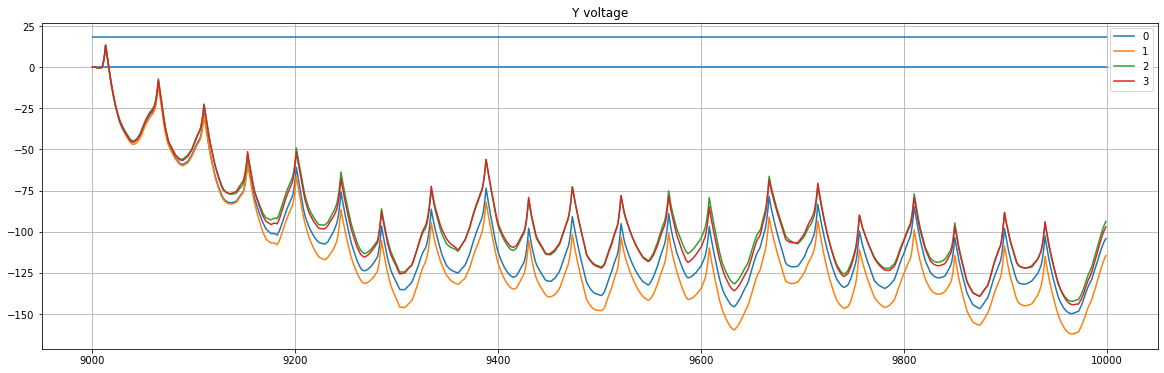

In [52]:


print('Begin training.\n');
start = t()
n_train = int(len_dataset*10)
progress_interval = 1 

weights_total = torch.Tensor()
voltages_total = torch.Tensor()


for i in range(n_train):
    
    if i % progress_interval == 0:
        print('Progress: %d / %d (%.4f seconds)' % (i, n_train, t() - start));
        start = t()

    
    sample = next(data_loader)
    sample_2 = next(data_loader_2)
    
    #print(input_data_2[i])
    
    inpts = {'X': sample, 'Y': sample_2} 

    
    network.run(inpts=inpts, time=time)
    
    
    recordings = network.monitors['Network'].get()
    
    
    if (i+1) % 20 == 0:
        sum_up = 0
        sum_down = 0
        count_up = 0
        count_down = 0
        weights_1 = recordings[('X', 'H')]['w'].view(-1, 500)
        weights_2 = weights_1[-1].view(50, 10)
        
        for i in range(10):
    
            temp = torch.tensor(digits[i]).reshape(1,25)
    
            for k in range(25):
        
                if temp[0][k] >= 0.5:
                    sum_up += weights_2[k][i]
                    count_up += 1
                else:
                    sum_down += weights_2[k][i]
                    count_down += 1
                    
            for k in range(25,50):
        
                if temp[0][k-25] < 0.5:
                    sum_up += weights_2[k][i]
                    count_up += 1
                else:
                    sum_down += weights_2[k][i]
                    count_down += 1
                    
        metrics.append((sum_up/count_up) - (sum_down/count_down))                    
    
    #network.reset_()

    fig_w = plt.figure(figsize=(20, 6))
    """
    plt.subplot(4,1,1)
    plt.title('H spikes')
    spikes = recordings[('H')]['s']
    for j in range(spikes.size(2)):
        #plt.plot(np.arange(i*spikes.size(0), (i+1)*spikes.size(0)), spikes[:,:,j].numpy(), label=str(j))
        plt.scatter(np.arange(i*spikes.size(0), (i+1)*spikes.size(0)), spikes[:,:,j].numpy(), label=str(j))
    plt.legend(loc='upper right')
    plt.ylim(-0.05, 1.05)
    plt.grid()
    
    plt.subplot(3,1,1)
    plt.title('Inhibitor spikes')
    spikes = recordings[('Y')]['s']
    for j in range(spikes.size(2)):
        #plt.plot(np.arange(i*spikes.size(0), (i+1)*spikes.size(0)), spikes[:,:,j].numpy(), label=str(j))
        plt.scatter(np.arange(i*spikes.size(0), (i+1)*spikes.size(0)), spikes[:,:,j].numpy(), label=str(j))
    plt.legend(loc='upper right')
    plt.ylim(-0.05, 1.05)
    plt.grid()
    
    
    # Spikes
    plt.subplot(3,1,2)
    plt.title('X spikes')
    spikes = recordings[('X')]['s'][:,:,0:6]
    for j in range(spikes.size(2)):
        #plt.plot(np.arange(i*spikes.size(0), (i+1)*spikes.size(0)), spikes[:,:,j].numpy(), label=str(j))
        plt.scatter(np.arange(i*spikes.size(0), (i+1)*spikes.size(0)), spikes[:,:,j].numpy(), label=str(j))
    plt.legend(loc='upper right')
    plt.ylim(-0.05, 1.05)
    plt.grid()
    """
    #Y Voltages
    plt.subplot(1,1,1)
    plt.title('Y voltage')
    voltages = recordings[('H')]['v']
    for j in range(4): #для первых 4 выходов
        plt.plot(np.arange(i*voltages.size(0), (i+1)*voltages.size(0)), voltages[:,:,j].numpy(), label=str(j))
    plt.legend(loc='upper right')
    plt.hlines([reset, thresh], i*voltages.size(0), (i+1)*voltages.size(0))
    plt.grid()

    display.clear_output(wait=True)
    display.display(fig_w, display_id = 'weights')
    
    
    network.reset_()  # Reset state variables
    
    plt.close(fig_w)
    

In [53]:
sum_up = 0
sum_down = 0
count_up = 0
count_down = 0
weights_1 = recordings[('X', 'H')]['w'].view(-1, 500)
weights_2 = weights_1[-1].view(50, 10)

weights_temp = torch.zeros(1,25)

for i in range(10):
    
    temp = torch.tensor(digits[i]).reshape(1,25)
    
    for k in range(25):
                
        weights_temp[0][k] = weights_2[k][i]
                
    px.imshow(weights_temp.view(5,5), width=350, height=350).show()

In [54]:
weights_temp = torch.zeros(1,25)

for i in range(10):
    
    temp = torch.tensor(digits[i]).reshape(1,25)
    
    for k in range(25,50):
                
        weights_temp[0][k-25] = weights_2[k][i]
        
                
    px.imshow(weights_temp.view(5,5), width=350, height=350).show()

In [55]:
#metrics.insert(0,torch.tensor(0))
metrics

[tensor(0),
 tensor(0.0207),
 tensor(0.0418),
 tensor(0.0668),
 tensor(0.0858),
 tensor(0.1069),
 tensor(0.1245),
 tensor(0.1400),
 tensor(0.1535),
 tensor(0.1736),
 tensor(0.1897),
 tensor(0.2053),
 tensor(0.2225),
 tensor(0.2363),
 tensor(0.2539),
 tensor(0.2718),
 tensor(0.2839),
 tensor(0.2954),
 tensor(0.3077),
 tensor(0.3194),
 tensor(0.3281),
 tensor(0.3375),
 tensor(0.3468),
 tensor(0.3568),
 tensor(0.3643),
 tensor(0.3698),
 tensor(0.3774),
 tensor(0.3852),
 tensor(0.3923),
 tensor(0.4001),
 tensor(0.4076)]

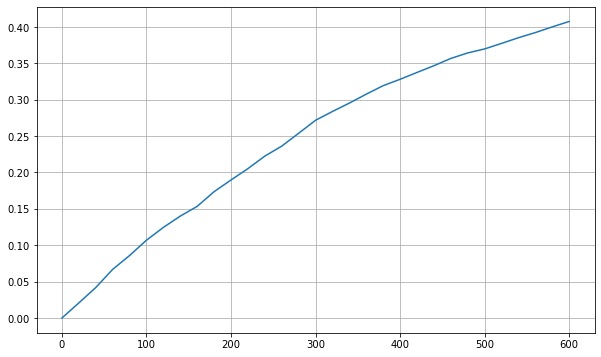

In [56]:
fig_w = plt.figure(figsize=(10, 6))
plt.plot(np.arange(0,20*len(metrics),20), metrics)
plt.grid()


In [57]:
#get weights
weights_1 = recordings[('X', 'H')]['w'].view(-1, 500)
weights_init_XH_1 = weights_1[-1].view(50, 10)


In [58]:
fl = open("C:/Users/Всеволод/Desktop/Weights.txt",'w')
for line in range(50):
    for value in range(10):
        fl.write(str(float(weights_init_XH_1[line][value]))+' ')
    fl.write('\n')
fl.close()

In [59]:

network_1 = Network()
input_layer_1 = Input(n=50, 
                    traces=True, 
                    thresh=thresh,
                    rest = reset,
                    reset=reset,
                    refrac=refrac)

hidden_layer_1 = LIFNodes(n=10, 
                     traces=True, 
                     thresh=thresh,
                     rest = reset,
                     reset=reset,
                     refrac=refrac)


conn_XH_1 = Connection(input_layer_1, 
                       hidden_layer_1, 
                       impulse_amplitude = 0.42,
                       impulse_length = 40,
                       impulse_shape_factor = 0.9,
                       invert = True,
                       update_rule=NoOp, 
                       w=weights_init_XH_1, 
                       nu=[learning_rate, learning_rate], 
                       wmin=wmin, 
                       wmax=wmax,
                       weight_decay=0
                      )



network_1.add_layer(input_layer_1, name='X_1')
network_1.add_layer(hidden_layer_1, name='H_1')

network_1.add_connection(conn_XH_1, source='X_1', target='H_1')

GlobalMonitor_1 = NetworkMonitor(network_1, state_vars=('v', 's', 'w'))
network_1.add_monitor(GlobalMonitor_1, name='Network_1')

print('GlobalMonitor.state_vars:', GlobalMonitor_1.state_vars)

GlobalMonitor.state_vars: ('v', 's', 'w')


In [64]:
time_1 = 20000
len_dataset_1 = 1

input_data, check_data  = stupid_digits_dataset(len_dataset_1, validation=True)
 
input_data *= intensity


data_loader = bernoulli_loader(data=(input_data/1000)*dt, time = time_1)

n_train = input_data.shape[0] 
progress_interval = 1 

accuracy = 0.0

for i in range(n_train):
 
    sample = next(data_loader)
    
    inpts = {'X_1': sample} 
    
    network_1.run(inpts=inpts, time = time_1)
        
    recordings = network_1.monitors['Network_1'].get()
    
    spikes = recordings[('H_1')]['s']
    
    responds = [0]*spikes.size(2)
    
    for neuron in range(spikes.size(2)):
        for k in range(spikes.size(0)):
        
            responds[neuron] += spikes[k,0,neuron].numpy()
        
    max_ = 0
    index_max = 0
    
    for index in range(len(responds)):
        
        if responds[index] > max_:
            max_ = responds[index]
            index_max = index
            
    print(responds)
    
    if check_data[i][index_max] >= 0.5:
        
        accuracy+=1
        
    network_1.reset_()
    
        
accuracy = accuracy/n_train
print(accuracy)

[332.0, 317.0, 322.0, 316.0, 315.0, 321.0, 324.0, 315.0, 325.0, 323.0]
[313.0, 333.0, 310.0, 316.0, 308.0, 315.0, 314.0, 324.0, 309.0, 311.0]
[318.0, 311.0, 338.0, 330.0, 325.0, 333.0, 333.0, 324.0, 333.0, 334.0]
[312.0, 317.0, 328.0, 333.0, 323.0, 326.0, 327.0, 328.0, 325.0, 329.0]
[315.0, 307.0, 320.0, 320.0, 334.0, 324.0, 324.0, 315.0, 324.0, 325.0]
[314.0, 311.0, 327.0, 327.0, 324.0, 335.0, 334.0, 313.0, 327.0, 332.0]
[319.0, 309.0, 329.0, 322.0, 321.0, 331.0, 335.0, 312.0, 330.0, 329.0]
[317.0, 323.0, 325.0, 326.0, 316.0, 318.0, 318.0, 335.0, 318.0, 320.0]
[321.0, 311.0, 331.0, 326.0, 326.0, 330.0, 331.0, 321.0, 332.0, 330.0]
[321.0, 312.0, 332.0, 331.0, 328.0, 334.0, 333.0, 322.0, 334.0, 335.0]
1.0
